# Before you get started

## Data formatting

MINER is optimized for expression data of the form log2(TPM+1) or log2(FPKM+1). Expression data in counts format is not currently supported. If your data is in counts format, consider first transforming to log2(cpm+1) with edgeR.

If expression data is not Homo Sapiens, a reference database must be provided for mechanistic inference.

# Begin miner analysis

## Import standard dependencies

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from numpy import random as rd
import os
import json
from sklearn.decomposition import PCA
import multiprocessing, multiprocessing.pool
import matplotlib.pyplot as plt
import seaborn as sns
import time
from collections import Counter
from sklearn.manifold import TSNE
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn import metrics
from sklearn import tree
import sys
sys.path.insert(0, os.path.expanduser('~/Desktop/miner3/miner/src'))
import miner_py3 as miner
%matplotlib inline
plt.style.use('ggplot')

## Create directory to save output files

In [2]:
# Path to the miner directory
base_dir = os.path.expanduser('~/Desktop/miner3/miner')
input_path = base_dir

# create name for results folder where output files will be saved
resultsFolder = "TCGA_UVM_network_results"

# create results directory
resultsDirectory = os.path.join(base_dir, resultsFolder)
if not os.path.isdir(resultsDirectory):
    os.makedirs(resultsDirectory)

## Load reference dictionary for mechanistic inference (skip if using default)

In [3]:
# #provide absolute path to your .csv-format reference database
# filename = os.path.join(os.path.split(os.getcwd())[0],"data","reference_database_example.csv")
# #provide absolute path to the miner/data/network_dictionaries directory where your database will be stored
# network_dictionaries_path = os.path.join(os.path.split(os.getcwd())[0],"data","network_dictionaries")
# #name your reference database and use the extension ".pkl"
# dictionaryName = "reference_database.pkl"
# #import and save your reference database to the Python pickle format for future use
# reference_mechanistic_database = miner.fileToReferenceDictionary(filename,os.path.join(network_dictionaries_path,dictionaryName))

## 0. Load and pre-process data; set parameters

In [4]:
# Load expression Data
expressionFile = os.path.join(base_dir, "data", "expression", "TCGA_UVM", "TCGA_UVM_Zscore.csv")
expressionData = pd.read_csv(expressionFile, index_col=0, header=0)
conversionTable = {}   # empty — already using gene symbols

Text(0.5, 0, 'Relative expression')

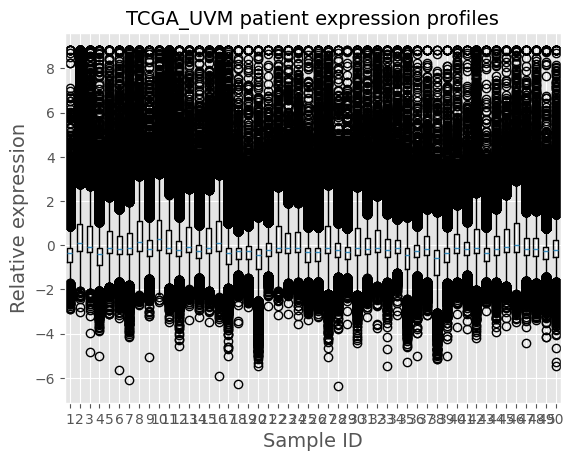

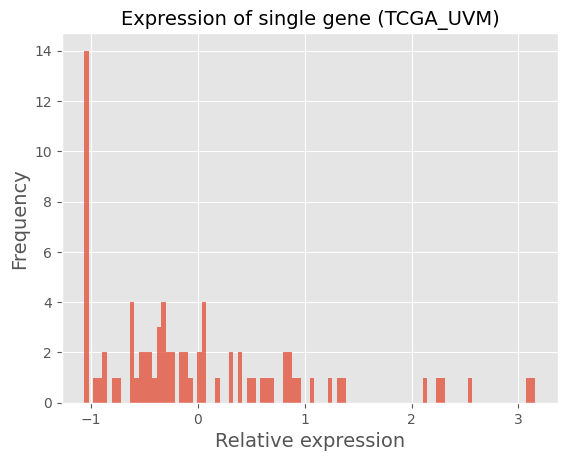

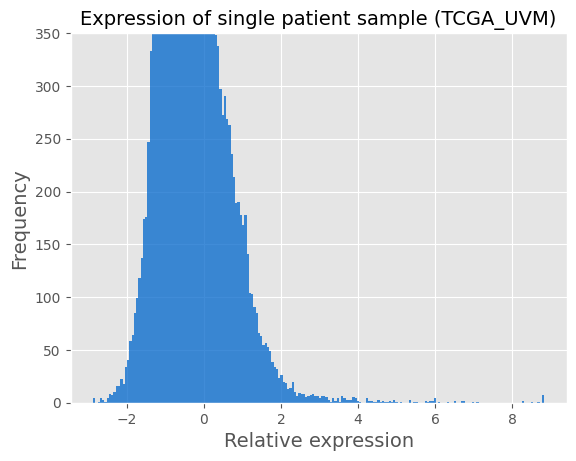

In [5]:
# Visualize pre-processed expression data
individual_expression_data = [expressionData.iloc[:,i] for i in range(50)]
_ = plt.boxplot(individual_expression_data)
plt.title("TCGA_UVM patient expression profiles", fontsize=14)   # ← changed
plt.ylabel("Relative expression", fontsize=14)
plt.xlabel("Sample ID", fontsize=14)
plt.figure()
_ = plt.hist(expressionData.iloc[0, :], bins=100, alpha=0.75)
plt.title("Expression of single gene (TCGA_UVM)", fontsize=14)   # ← changed
plt.ylabel("Frequency", fontsize=14)
plt.xlabel("Relative expression", fontsize=14)
plt.figure()
_ = plt.hist(expressionData.iloc[:,0],bins=200,color=[0,0.4,0.8],alpha=0.75)
plt.ylim(0,350)
plt.title("Expression of single patient sample (TCGA_UVM)",fontsize=14)
plt.ylabel("Frequency",fontsize=14)
plt.xlabel("Relative expression",fontsize=14)

## Set parameters

In [6]:
# minimum number of genes that form an acceptable coexpression cluster:
minNumberGenes = 6 #bulk RNAseq default=6;single cell RNAseq default=6

# minimum correlation coefficient for an acceptable regulator-cluster association 
minCorrelation = 0.2 #bulk RNAseq default=0.2;single cell RNAseq default=0.05

# minimum number of genes that form an acceptable coexpression cluster and have share binding site for regulator:
minNumberRegulonGenes = 5 #bulk RNAseq default=5;single cell RNAseq default=4

# choose database: if supplying your own database, use mechanistic_database = reference_mechanistic_database
mechanistic_database = os.path.expanduser(
    '~/Desktop/miner3/miner/data/network_dictionaries/tfbsdb_tf_to_genes_symbol.pkl'
)
#mechanistic_database = reference_mechanistic_database #use if supplying your own database

# number of cores available for multiprocessing
numCores = 5

# 1. Co-expression clustering

0.00 percent complete
20.00 percent complete
40.00 percent complete
60.00 percent complete
80.00 percent complete

coexpression clustering completed in 1.21 minutes
Completed coexpression clustering in 4.18 minutes
Number of genes clustered: 32959
Number of unique clusters: 1719
Completed clustering module in 4.18 minutes


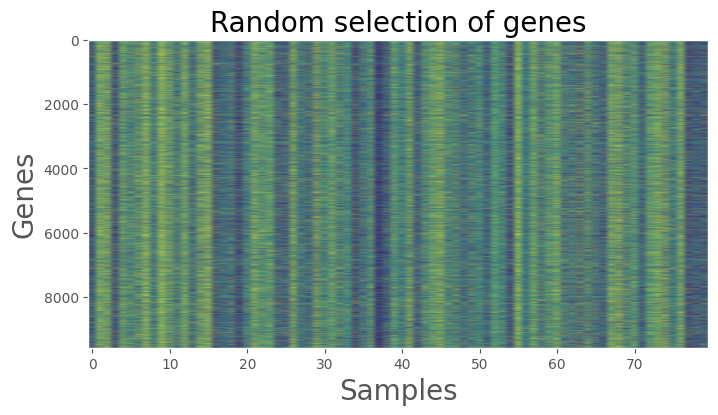

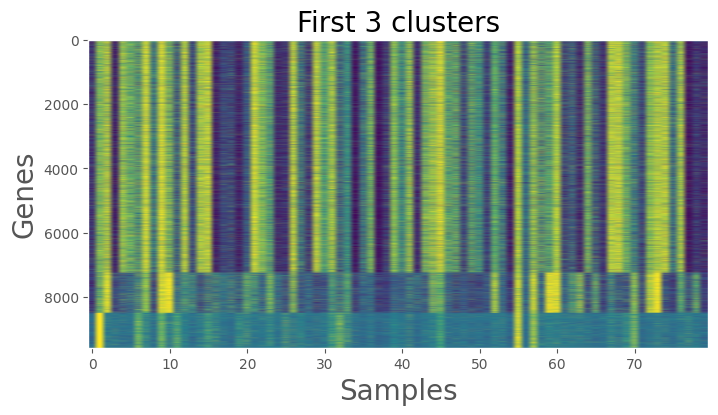

In [7]:
# Network inference may take several minutes. 
# Prompts will print at 0, 20, 40, 60, 80, and 100% complete

t1 = time.time() 
# generate a list of coexpressed gene clusters, all of which have length >= minNumberGenes
initialClusters = miner.cluster(expressionData,minNumberGenes = minNumberGenes,minNumberOverExpSamples=4,maxSamplesExcluded=0.50,random_state=17,overExpressionThreshold=80) 
# revise initialClusters to combine highly correlated clusters and keep only those with significant coexpression
revisedClusters = miner.reviseInitialClusters(initialClusters,expressionData)
# write revisedClusters to .json file
miner.write_json(revisedClusters,os.path.join(resultsDirectory,"coexpressionDictionary.json"))
t2 = time.time()
print("Completed coexpression clustering in {:.2f} minutes".format((t2-t1)/60.))

# retrieve first three clusters for visual inspection
first_clusters = np.hstack([revisedClusters[i] for i in np.arange(3).astype(str)])

# visualize background expression
plt.figure(figsize=(8,4))
plt.imshow(expressionData.loc[np.random.choice(
    expressionData.index,len(first_clusters),
    replace=False),:],aspect="auto",cmap="viridis",vmin=-1,vmax=1)
plt.grid(False)
plt.ylabel("Genes",fontsize=20)
plt.xlabel("Samples",fontsize=20)
plt.title("Random selection of genes",fontsize=20)

# visualize first 10 clusters
plt.figure(figsize=(8,4))
plt.imshow(expressionData.loc[first_clusters,:],aspect="auto",cmap="viridis",vmin=-1,vmax=1)
plt.grid(False)
plt.ylabel("Genes",fontsize=20)
plt.xlabel("Samples",fontsize=20)
plt.title("First 3 clusters",fontsize=20)

# report coverage
print("Number of genes clustered: {:d}".format(len(set(np.hstack(initialClusters)))))
print("Number of unique clusters: {:d}".format(len(revisedClusters)))

t3 = time.time()
print("Completed clustering module in {:.2f} minutes".format((t3-t1)/60.))

# 2. Mechanistic inference

In [8]:
import pickle
import pandas as pd

# Load the identifier mappings file already in your data folder
mapping_file = os.path.expanduser('~/Desktop/miner3/miner/data/identifier_mappings.txt')
mapping_df = pd.read_csv(mapping_file, sep='\t', header=0)
print("Columns:", mapping_df.columns.tolist())
print("Shape:", mapping_df.shape)
print(mapping_df.head())

Columns: ['Preferred_Name', 'Name', 'Source']
Shape: (301116, 3)
    Preferred_Name             Name              Source
0  ENSG00000000003  ENSG00000000003     Ensembl Gene ID
1  ENSG00000000003  ENSP00000362111  Ensembl Protein ID
2  ENSG00000000003  ENSP00000482130  Ensembl Protein ID
3  ENSG00000000003  ENSP00000482894  Ensembl Protein ID
4  ENSG00000000003             7105      Entrez Gene ID


In [9]:
# Filter rows where Source is Gene Name
gene_name_rows = mapping_df[mapping_df['Source'] == 'Gene Name']
print("Gene Name rows found:", len(gene_name_rows))
print(gene_name_rows.head())

# Build Ensembl → symbol dict
ensembl_to_symbol = dict(zip(gene_name_rows['Preferred_Name'], gene_name_rows['Name']))
ensembl_to_symbol = {k: v for k, v in ensembl_to_symbol.items() 
                     if pd.notna(k) and pd.notna(v)}
print(f"Mapped {len(ensembl_to_symbol)} Ensembl IDs to symbols")
print("Sample:", list(ensembl_to_symbol.items())[:5])

# Load the existing Ensembl-based database
db_path = os.path.expanduser('~/Desktop/miner3/miner/data/network_dictionaries/tfbsdb_tf_to_genes.pkl')
with open(db_path, 'rb') as f:
    tfdb_ensembl = pickle.load(f)

# Rebuild with gene symbols
tfdb_symbols = {}
for tf_ensembl, target_ensembls in tfdb_ensembl.items():
    tf_symbol = ensembl_to_symbol.get(tf_ensembl)
    if tf_symbol is None:
        continue
    target_symbols = [ensembl_to_symbol[g] for g in target_ensembls 
                      if g in ensembl_to_symbol]
    if target_symbols:
        tfdb_symbols[tf_symbol] = target_symbols

print(f"Rebuilt database has {len(tfdb_symbols)} TFs")
print("Sample keys:", list(tfdb_symbols.keys())[:5])

# Save
out_path = os.path.expanduser(
    '~/Desktop/miner3/miner/data/network_dictionaries/tfbsdb_tf_to_genes_symbol.pkl'
)
with open(out_path, 'wb') as f:
    pickle.dump(tfdb_symbols, f)
print(f"Saved to: {out_path}")

Gene Name rows found: 20055
     Preferred_Name      Name     Source
5   ENSG00000000003    TSPAN6  Gene Name
22  ENSG00000000005      TNMD  Gene Name
37  ENSG00000000419      DPM1  Gene Name
53  ENSG00000000457     SCYL3  Gene Name
71  ENSG00000000460  C1orf112  Gene Name
Mapped 20055 Ensembl IDs to symbols
Sample: [('ENSG00000000003', 'TSPAN6'), ('ENSG00000000005', 'TNMD'), ('ENSG00000000419', 'DPM1'), ('ENSG00000000457', 'SCYL3'), ('ENSG00000000460', 'C1orf112')]
Rebuilt database has 664 TFs
Sample keys: ['ETS1', 'HOXA6', 'SNAI2', 'HOXA5', 'ZKSCAN3']
Saved to: /Users/sanskrutik/Desktop/miner3/miner/data/network_dictionaries/tfbsdb_tf_to_genes_symbol.pkl


In [10]:
# Strip version suffixes from Ensembl IDs in the mapping
ensembl_to_symbol_versioned = {}
for k, v in ensembl_to_symbol.items():
    # k is like ENSG00000227232, add both bare and .X versions
    ensembl_to_symbol_versioned[k] = v

# Build a version-aware lookup
def lookup_symbol(ensembl_id):
    # Try exact match first
    if ensembl_id in ensembl_to_symbol:
        return ensembl_to_symbol[ensembl_id]
    # Try stripping version suffix
    bare = ensembl_id.split('.')[0]
    return ensembl_to_symbol.get(bare, ensembl_id)  # falls back to original ID

print("Test:", lookup_symbol('ENSG00000227232.5'))

Test: ENSG00000227232.5


In [11]:
# Remap expressionData index — strip version AND convert to symbol where possible
def lookup_symbol(ensembl_id):
    bare = ensembl_id.split('.')[0]  # always strip version first
    return ensembl_to_symbol.get(bare, bare)  # return symbol or bare ID

new_index = [lookup_symbol(g) for g in expressionData.index]
expressionData.index = new_index
print("expressionData index sample:", expressionData.index[:5].tolist())
print("Any versioned IDs remaining?", any('.' in str(x) for x in expressionData.index))

expressionData index sample: ['5S_rRNA', '7SK', 'A1BG', 'A1BG-AS1', 'A1CF']
Any versioned IDs remaining? False


In [12]:
revisedClusters = {
    k: [lookup_symbol(g) for g in genes]
    for k, genes in revisedClusters.items()
}
# Verify
sample_cluster = list(revisedClusters.keys())[0]
print("Cluster genes after remap:", list(revisedClusters[sample_cluster])[:5])

Cluster genes after remap: ['LOC100420707', 'IDE', 'SNORA67', 'SHOC2', 'WDR12']


In [13]:
t1 = time.time()
# get first principal component axes of clusters
axes = miner.principalDf(revisedClusters,expressionData,subkey=None,minNumberGenes=1)
# analyze revised clusters for enrichment in relational database (default: transcription factor binding site database)
mechanisticOutput = miner.mechanisticInference(axes,revisedClusters,expressionData,correlationThreshold=minCorrelation,numCores=numCores,database=mechanistic_database)
# write mechanistic output to .json file
miner.write_json(mechanisticOutput,os.path.join(resultsDirectory,"mechanisticOutput.json"))
# order mechanisticOutput as {tf:{coexpressionModule:genes}} 
coregulationModules = miner.getCoregulationModules(mechanisticOutput)
# write coregulation modules to .json file
miner.write_json(coregulationModules,os.path.join(resultsDirectory,"coregulationModules.json"))
# get final regulons by keeping genes that requently appear coexpressed and associated to a common regulator
regulons = miner.getRegulons(coregulationModules,minNumberGenes=minNumberRegulonGenes,freqThreshold = 0.333)
# reformat regulon dictionary for consistency with revisedClusters and coexpressionModules
regulonModules, regulonDf = miner.regulonDictionary(regulons)
# write regulonDf to csv using preferred gene name identifiers
regulonDf.to_csv(os.path.join(resultsDirectory,"regulonDf.csv"))
# write regulons to json file
miner.write_json(regulonModules,os.path.join(resultsDirectory,"regulons.json"))
# define coexpression modules as composite of coexpressed regulons
coexpressionModules = miner.getCoexpressionModules(mechanisticOutput)
# write coexpression modules to .json file
miner.write_json(coexpressionModules,os.path.join(resultsDirectory,"coexpressionModules.json"))
# Get eigengenes for all modules
try:
    eigengenes = miner.getEigengenes(regulonModules,expressionData,regulon_dict=None,saveFolder=None)
    eigenScale = np.percentile(expressionData,95)/np.percentile(eigengenes,95)
    eigengenes = eigenScale*eigengenes
    eigengenes.index = np.array(eigengenes.index).astype(str)
    eigengenes.to_csv(os.path.join(resultsDirectory,"eigengenes.csv"))
    print("Eigengenes saved successfully")
except Exception as e:
    print("Eigengenes skipped:", e)
    eigengenes = None

t2 = time.time()
print("Completed mechanistic inference in {:.2f} minutes".format((t2-t1)/60.))
print("Inferred network with {:d} regulons, {:d} regulators, and {:d} co-regulated genes".format(len(regulonDf.Regulon_ID.unique()),len(regulonDf.Regulator.unique()),len(regulonDf.Gene.unique())))

Running mechanistic inference
Eigengenes saved successfully
Completed mechanistic inference in 12.29 minutes
Inferred network with 8715 regulons, 626 regulators, and 10930 co-regulated genes


In [14]:
import sys
print(sys.executable)

/opt/anaconda3/envs/miner_env/bin/python


# 3. Expand regulons (optional, not default)

t1 = time.time()
tfbsdbGenes_file = os.path.join(input_path,"data","network_dictionaries","tfbsdb_genes_to_tf.pkl")
expandedRegulons = miner.parallelRegulonExpansion(eigengenes,regulonModules,regulonDf,
                                                  expressionData,tfbsdbGenes_file,
                                                  overExpressedMembersMatrix,
                                                  corrThreshold = 0.25,auc_threshold = 0.70,
                                                  numCores=5)

regulonIDtoRegulator = miner.regulonIdToRegulator(regulonDf)
expandedRegulonDf = miner.regulonDictToDf(expandedRegulons,regulonIDtoRegulator)
t2 = time.time()
print("Completed regulon expansion in {:.2f} minutes".format((t2-t1)/float(60.)))

expandedEigengenes = miner.getEigengenes(expandedRegulons,expressionData,regulon_dict=None,saveFolder=None)
eigenScale = np.percentile(expressionData,95)/np.percentile(expandedEigengenes,95)
expandedEigengenes = eigenScale*expandedEigengenes
expandedEigengenes.index = np.array(expandedEigengenes.index).astype(str)

expandedEigengenes.to_csv(os.path.join(resultsDirectory,"expanded_eigengenes.csv"))
expandedRegulonDf.to_csv(os.path.join(resultsDirectory,"expanded_regulonDf.csv"))
miner.write_json(expandedRegulons,os.path.join(resultsDirectory,"expanded_regulons.json"))
print("Expanded network to {:d} regulons, {:d} regulators, and {:d} co-regulated genes".format(len(expandedRegulonDf.Regulon_ID.unique()),
                                                                                                 len(expandedRegulonDf.Regulator.unique()),
                                                                                                 len(expandedRegulonDf.Gene.unique())))

# 4. Causal inference

# Load mutation matrices
common_mutations_file = os.path.join(os.path.split(os.getcwd())[0],"data","mutations","commonMutations.csv")
common_mutations = pd.read_csv(common_mutations_file,index_col=0,header=0)

translocations_file = os.path.join(os.path.split(os.getcwd())[0],"data","mutations","translocationsIA12.csv")
translocations = pd.read_csv(translocations_file,index_col=0,header=0)

cytogenetics_file = os.path.join(os.path.split(os.getcwd())[0],"data","mutations","cytogenetics.csv")
cytogenetics = pd.read_csv(cytogenetics_file,index_col=0,header=0)

# Perform causal analysis for each mutation matrix
mut_matrix = common_mutations.copy()
referenceDictionary = regulonModules
referenceRegulonDf = regulonDf
referenceDf = eigengenes

miner.causalNetworkAnalysis(regulon_matrix=referenceRegulonDf.copy(),expression_matrix=expressionData.copy(),reference_matrix=referenceDf.copy(),mutation_matrix=mut_matrix,resultsDirectory=os.path.join(resultsDirectory,"causal_analysis"),minRegulons=1,significance_threshold=0.05,causalFolder="causal_results_common_mutations")

mut_matrix = translocations.copy()
miner.causalNetworkAnalysis(regulon_matrix=referenceRegulonDf.copy(),expression_matrix=expressionData.copy(),reference_matrix=referenceDf.copy(),mutation_matrix=mut_matrix,resultsDirectory=os.path.join(resultsDirectory,"causal_analysis"),minRegulons=1,significance_threshold=0.05,causalFolder="causal_results_translocations")

mut_matrix = cytogenetics.copy()
miner.causalNetworkAnalysis(regulon_matrix=referenceRegulonDf.copy(),expression_matrix=expressionData.copy(),reference_matrix=referenceDf.copy(),mutation_matrix=mut_matrix,resultsDirectory=os.path.join(resultsDirectory,"causal_analysis"),minRegulons=1,significance_threshold=0.05,causalFolder="causal_results_cytogenetics")

# compile all causal results
causal_directory = os.path.join(resultsDirectory,"causal_analysis")
causal_results = miner.readCausalFiles(causal_directory)
causal_results.to_csv(os.path.join(resultsDirectory,"completeCausalResults.csv"))
causal_results.head()

# filtered causal results
causal_results_regulon_filtered = causal_results[causal_results["-log10(p)_Regulon_stratification"]>=-np.log10(0.05)]
causal_results_aligned = causal_results_regulon_filtered[causal_results_regulon_filtered.Fraction_of_edges_correctly_aligned>=0.5]
causal_results_aligned_correlated = causal_results_aligned[causal_results_aligned["RegulatorRegulon_Spearman_p-value"]<=0.05]
causal_results_stratified_aligned_correlated = causal_results_aligned_correlated[causal_results_aligned_correlated["-log10(p)_MutationRegulatorEdge"]>=-np.log10(0.05)]

# for all causal flows, 
# the regulon is differentially active w.r.t the mutation,
# the regulator is differentially active w.r.t the mutation,
# the regulator is significantly correlated to the regulon,
# and the directionality of at least half of the differentially active targets 
# downstream of the regulator are consistent with the perturbation from the mutation

causal_results_stratified_aligned_correlated.to_csv(os.path.join(resultsDirectory,"filteredCausalResults.csv"))

# 5. Network mapping

In [15]:
t1 = time.time()
# select reference dictionary for downstream analysis (revisedClusters, coexpressionModules, or regulonModules)
referenceDictionary = regulonModules
# create a background matrix used for statistical hypothesis testing
bkgd = miner.backgroundDf(expressionData)
# for each cluster, give samples that show high coherent cluster activity
overExpressedMembers = miner.biclusterMembershipDictionary(referenceDictionary,bkgd,label=2,p=0.05)
# for each clus|ter, give samples that show low coherent cluster activity
underExpressedMembers = miner.biclusterMembershipDictionary(referenceDictionary,bkgd,label=0,p=0.05)
# for each cluster, give samples that do not show coherent cluster activity
# dysregulatedMembers = miner.biclusterMembershipDictionary(referenceDictionary,bkgd,label="excluded")
# # for each cluster, give samples that show coherent cluster activity, despite magnitude of expression
# coherentMembers = miner.biclusterMembershipDictionary(referenceDictionary,bkgd,label="included")

# write membership matrices to .csv file
overExpressedMembersMatrix = miner.membershipToIncidence(overExpressedMembers,expressionData)
overExpressedMembersMatrix.to_csv(os.path.join(resultsDirectory,"overExpressedMembers.csv"))
underExpressedMembersMatrix = miner.membershipToIncidence(underExpressedMembers,expressionData)
underExpressedMembersMatrix.to_csv(os.path.join(resultsDirectory,"underExpressedMembers.csv"))
# dysregulatedMembersMatrix = miner.membershipToIncidence(dysregulatedMembers,expressionData)
# dysregulatedMembersMatrix.to_csv(os.path.join(resultsDirectory,"dysregulatedMembers.csv"))
# coherentMembersMatrix = miner.membershipToIncidence(coherentMembers,expressionData)
# coherentMembersMatrix.to_csv(os.path.join(resultsDirectory,"coherentMembers.csv"))

t2 = time.time()
print("Completed patient mapping in {:.2f} minutes".format((t2-t1)/60.))

/Users/sanskrutik/Desktop/miner3/miner/src/miner_py3.py:1058: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  bkgd.iloc[:,i][bkgd.iloc[:,i]>=highCut]=1
/Users/sanskrutik/Desktop/miner3/miner/src/miner_py3.py:1059: FutureWarning: ChainedAssignm

done!
done!
Completed patient mapping in 0.13 minutes


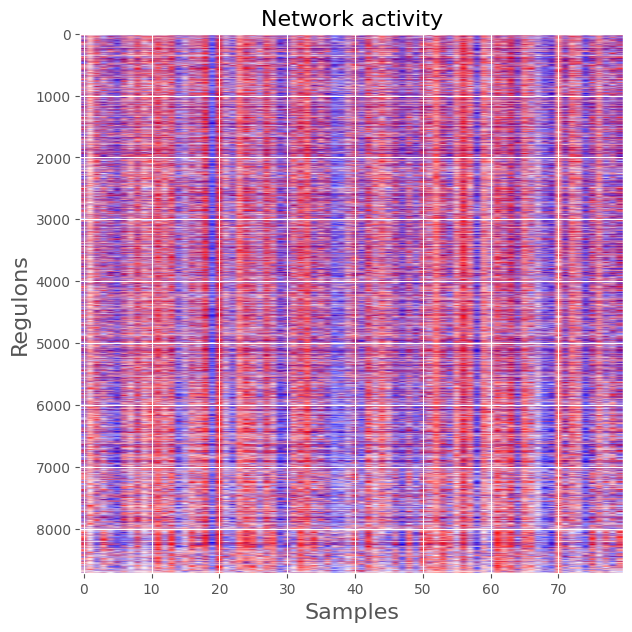

In [16]:
#visualize network activity across individual samples
plt.figure(figsize=(7,7))
network_activity_heatmap = overExpressedMembersMatrix-underExpressedMembersMatrix
plt.imshow(network_activity_heatmap,cmap="bwr",vmin=-1,vmax=1,aspect="auto")
plt.title("Network activity",fontsize=16)
plt.ylabel("Regulons",fontsize=16)
plt.xlabel("Samples",fontsize=16)
plt.savefig(os.path.join(resultsDirectory, 'network_activity_heatmap.png'), 
            format='png', dpi=150, bbox_inches='tight')

# 6. Subtype discovery

In [17]:
# Fix pandas 3.x set indexer incompatibility and reload miner
with open('/Users/sanskrutik/Desktop/miner3/miner/src/miner_py3.py', 'r') as f:
    content = f.read()

old = '    similarityMatrix = similarityMatrix.loc[predictedNonMembers,predictedNonMembers]'
new = '    similarityMatrix = similarityMatrix.loc[list(predictedNonMembers),list(predictedNonMembers)]'

new_content = content.replace(old, new)
if new_content == content:
    print("Pattern not found")
else:
    with open('/Users/sanskrutik/Desktop/miner3/miner/src/miner_py3.py', 'w') as f:
        f.write(new_content)
    print("File patched!")

import importlib, sys
for key in list(sys.modules.keys()):
    if 'miner' in key.lower():
        del sys.modules[key]
sys.path.insert(0, '/Users/sanskrutik/Desktop/miner3/miner/src')
import miner_py3 as miner

Pattern not found


In [18]:
import importlib, sys
for key in list(sys.modules.keys()):
    if 'miner' in key.lower():
        del sys.modules[key]
sys.path.insert(0, '/Users/sanskrutik/Desktop/miner3/miner/src')
import miner_py3 as miner
print("Reloaded! principalDf available:", hasattr(miner, 'principalDf'))

Reloaded! principalDf available: True


In [19]:
# Infer transcriptional states
minClusterSize = int(np.ceil(0.01*expressionData.shape[1]))
referenceMatrix = overExpressedMembersMatrix-underExpressedMembersMatrix
primaryMatrix = overExpressedMembersMatrix
primaryDictionary = overExpressedMembers
secondaryMatrix = underExpressedMembersMatrix
secondaryDictionary = underExpressedMembers

states, centroidClusters = miner.inferSubtypes(referenceMatrix,primaryMatrix,secondaryMatrix,primaryDictionary,secondaryDictionary,minClusterSize = int(np.ceil(0.01*expressionData.shape[1])),restricted_index=None)
states_dictionary = {str(i):states[i] for i in range(len(states))}
miner.write_json(states_dictionary,os.path.join(resultsDirectory,"transcriptional_states.json"))

Beginning subtype inference
completed subtype inference in 0.01 minutes


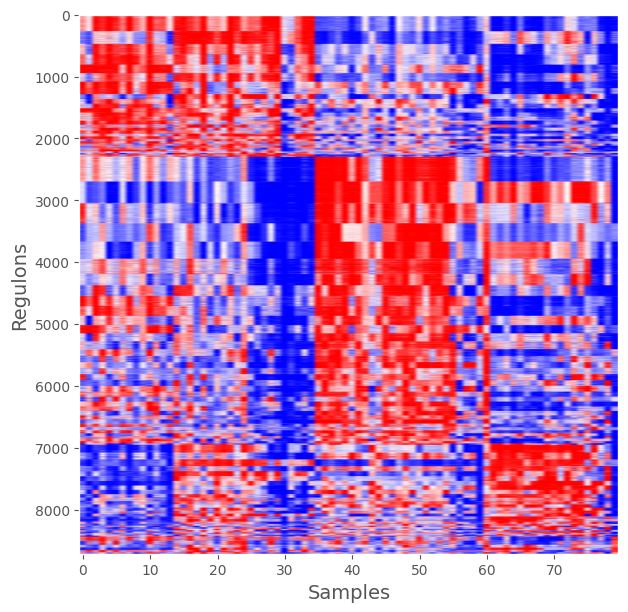

In [20]:
# Infer transcriptional programs
reference_df = eigengenes.copy()
programs, _ = miner.mosaic(dfr=reference_df,clusterList=centroidClusters,minClusterSize_x=int(np.ceil(0.01*expressionData.shape[1])),minClusterSize_y=5,allow_singletons=False,max_groups=50,saveFile=os.path.join(resultsDirectory,"regulon_activity_heatmap.pdf"),random_state=12)   
transcriptional_programs, program_regulons = miner.transcriptionalPrograms(programs,referenceDictionary)
program_list = [program_regulons[("").join(["TP",str(i)])] for i in range(len(program_regulons))]
programs_dictionary = {str(i):program_list[i] for i in range(len(program_list))}
miner.write_json(programs_dictionary,os.path.join(resultsDirectory,"transcriptional_programs.json"))
mosaicDf = reference_df.loc[np.hstack(program_list),np.hstack(states)]
mosaicDf.to_csv(os.path.join(resultsDirectory,"regulons_activity_heatmap.csv"))
plt.savefig(os.path.join(resultsDirectory, 'regulons_activity_heatmap.png'), 
            format='png', dpi=150, bbox_inches='tight')

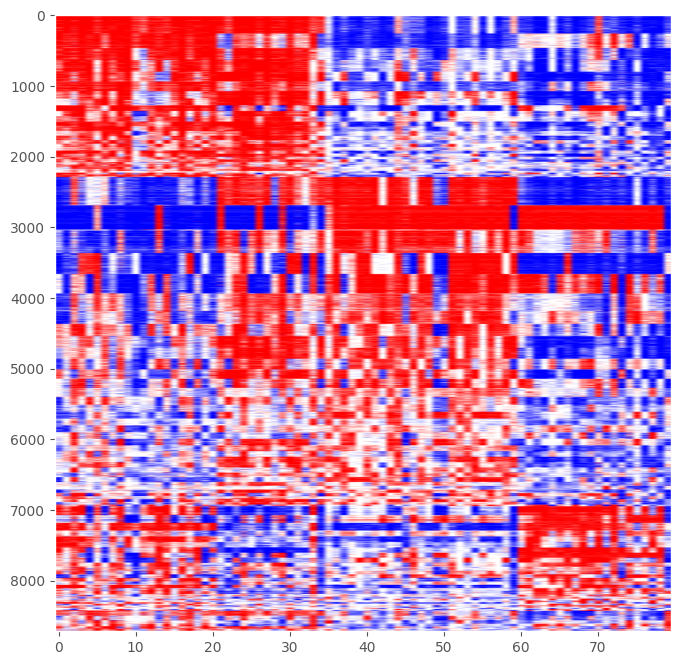

In [21]:
dfr = overExpressedMembersMatrix-underExpressedMembersMatrix
mtrx = dfr.loc[np.hstack(program_list),np.hstack(states)]
plt.figure(figsize=(8,8))
plt.imshow(mtrx,cmap="bwr",vmin=-1,vmax=1,aspect=float(mtrx.shape[1])/float(mtrx.shape[0]))
plt.grid(False)
plt.savefig(os.path.join(resultsDirectory,"mosaic_all.png"),bbox_inches="tight", dpi=150)

In [22]:
with open('/Users/sanskrutik/Desktop/miner3/miner/src/miner_py3.py', 'r') as f:
    content = f.read()

content = content.replace('FontSize=14', 'fontsize=14')

with open('/Users/sanskrutik/Desktop/miner3/miner/src/miner_py3.py', 'w') as f:
    f.write(content)
print("Fixed all FontSize → fontsize!")

# Reload miner
import sys
for key in list(sys.modules.keys()):
    if 'miner' in key.lower():
        del sys.modules[key]
sys.path.insert(0, '/Users/sanskrutik/Desktop/miner3/miner/src')
import miner_py3 as miner
print("Reloaded!")

Fixed all FontSize → fontsize!
Reloaded!


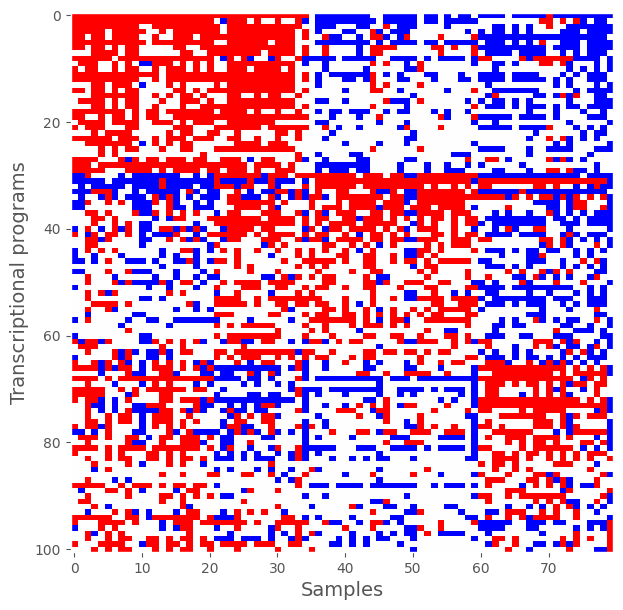

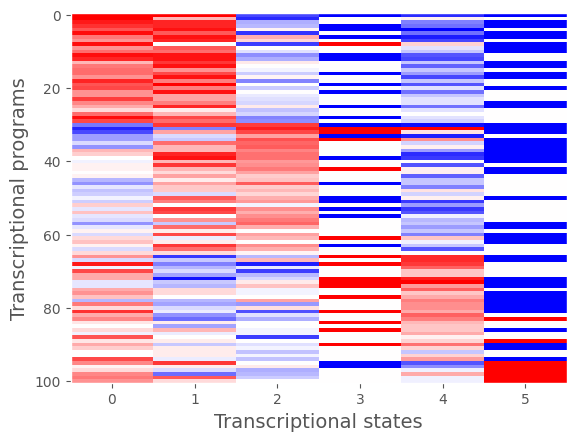

In [23]:
# Determine activity of transcriptional programs in each sample
statesDf = miner.reduceModules(df=dfr.loc[np.hstack(program_list),np.hstack(states)],programs=program_list,states=states,stateThreshold=0.50,saveFile=os.path.join(resultsDirectory,"transcriptional_programs.png"))

# Cluster patients into subtypes and give the activity of each program in each subtype
programsVsStates = miner.programsVsStates(statesDf,states,filename=os.path.join(resultsDirectory,"programs_vs_states.png"),showplot=True)